In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# If Dataset is in a module, import it:
from dataset import Dataset

# ----------------------------
# Config (edit these)
# ----------------------------
dataset_name = "pamap2"          # "census_income" or "pamap2"
multiclass   = False            # True if using 3-class PAMAP2 mode
minority_id  = 13               # PAMAP2: rope activity id (e.g., 24 if that’s your rope id in your mapping)
majority_id  = 4                # PAMAP2: walking activity id
third_id     = None             # e.g., 13 if using multiclass with a third activity
bias_pct     = 0.35

pca_components = 10             # the PCA dim the agent uses
train_size     = 3000
device         = "cpu"
seed           = 42

# Split fractions should match your training runs
val_frac  = 0.20
test_frac = 0.20

ds = Dataset(
    dataset_name=dataset_name,
    multiclass=multiclass,
    minority_id=minority_id,
    majority_id=majority_id,
    third_id=third_id,
    pca_components=pca_components,
    seed=seed,
    device=device,
)

Xtr, Xva, Xte, ytr, yva, yte = ds.get_data_splits(
    train_size=train_size,
    bias_pct=bias_pct,
    val_frac=val_frac,
    test_frac=test_frac,
    pca_components=pca_components,
)

def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

Xtr_np, Xva_np, Xte_np = to_np(Xtr), to_np(Xva), to_np(Xte)
ytr_np, yva_np, yte_np = to_np(ytr), to_np(yva), to_np(yte)

print("Shapes:")
print("  Train:", Xtr_np.shape, ytr_np.shape)
print("  Val:  ", Xva_np.shape, yva_np.shape)
print("  Test: ", Xte_np.shape, yte_np.shape)

print("Class balance (train/val/test):")
for name, y in [("train", ytr_np), ("val", yva_np), ("test", yte_np)]:
    vals, cnts = np.unique(y, return_counts=True)
    parts = ", ".join([f"{int(v)}:{int(c)}" for v, c in zip(vals, cnts)])
    print(f"  {name}: {parts}")


/home/epigou/cs_9170_project/dataset.py:284: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=717, rope=214 (29.85%), class0=503, class1=214
[VAL] size=310, rope=97 (31.29%), class0=213, class1=97
[TEST] size=335, rope=105 (31.34%), class0=230, class1=105
PCA comps: 10 | Features in: 14 | Classes: [np.int64(0), np.int64(1)]
Shapes:
  Train: (717, 10) (717,)
  Val:   (310, 10) (310,)
  Test:  (335, 10) (335,)
Class balance (train/val/test):
  train: 0:503, 1:214
  val: 0:213, 1:97
  test: 0:230, 1:105


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def pca_radius(X):
    # Radius in PCA space: ||x||_2 across ALL PCA dims the agent uses
    return np.linalg.norm(X, axis=1)

def summarize_split(name, X, y):
    r = pca_radius(X)
    print(f"\n[{name}] n={len(y)}")
    for cls in np.unique(y):
        m = (y == cls)
        rc = r[m]
        print(f"  class {int(cls)}: n={m.sum():5d}  radius mean={rc.mean():.3f}  p50={np.median(rc):.3f}  p90={np.quantile(rc,0.9):.3f}")

def plot_pca_scatter(X, y, title, max_points=20000):
    # PC1 vs PC2
    X2 = X[:, :2]
    n = X2.shape[0]
    if n > max_points:
        idx = np.random.RandomState(0).choice(n, size=max_points, replace=False)
        X2 = X2[idx]
        y = y[idx]

    plt.figure(figsize=(7,6))
    for cls in np.unique(y):
        m = (y == cls)
        plt.scatter(X2[m,0], X2[m,1], s=3, alpha=0.25, label=f"class {int(cls)}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

def plot_pca_heatmap(X, title, bins=120, range_xy=None):
    # Overall 2D density heatmap in PC1-PC2
    X2 = X[:, :2]
    x = X2[:,0]; y = X2[:,1]

    if range_xy is None:
        # robust limits
        xlo, xhi = np.quantile(x, [0.01, 0.99])
        ylo, yhi = np.quantile(y, [0.01, 0.99])
        range_xy = [[xlo, xhi], [ylo, yhi]]

    H, xedges, yedges = np.histogram2d(x, y, bins=bins, range=range_xy)

    plt.figure(figsize=(7,6))
    plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    )
    plt.colorbar(label="count")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()

def plot_class_heatmaps(X, y, title_prefix, bins=120, range_xy=None):
    # Consistent axes across classes
    X2 = X[:, :2]
    x = X2[:,0]; yy = X2[:,1]
    if range_xy is None:
        xlo, xhi = np.quantile(x, [0.01, 0.99])
        ylo, yhi = np.quantile(yy, [0.01, 0.99])
        range_xy = [[xlo, xhi], [ylo, yhi]]

    for cls in np.unique(y):
        m = (y == cls)
        plot_pca_heatmap(X[m], f"{title_prefix} — class {int(cls)}", bins=bins, range_xy=range_xy)

def plot_radius_curves(X, y, title):
    r = pca_radius(X)

    # Histogram
    plt.figure(figsize=(7,4))
    for cls in np.unique(y):
        rc = r[y == cls]
        plt.hist(rc, bins=60, alpha=0.5, density=True, label=f"class {int(cls)}")
    plt.xlabel("PCA radius ||x||")
    plt.ylabel("density")
    plt.title(title + " — radius histogram")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # CDF
    plt.figure(figsize=(7,4))
    for cls in np.unique(y):
        rc = np.sort(r[y == cls])
        cdf = np.linspace(0, 1, len(rc), endpoint=True)
        plt.plot(rc, cdf, label=f"class {int(cls)}")
    plt.xlabel("PCA radius ||x||")
    plt.ylabel("CDF")
    plt.title(title + " — radius CDF")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



[TRAIN] n=717
  class 0: n=  503  radius mean=2.422  p50=2.004  p90=3.752
  class 1: n=  214  radius mean=4.836  p50=4.018  p90=8.232

[VAL] n=310
  class 0: n=  213  radius mean=2.609  p50=2.226  p90=3.624
  class 1: n=   97  radius mean=5.259  p50=4.547  p90=8.559

[TEST] n=335
  class 0: n=  230  radius mean=2.571  p50=2.314  p90=3.366
  class 1: n=  105  radius mean=5.493  p50=4.958  p90=8.053


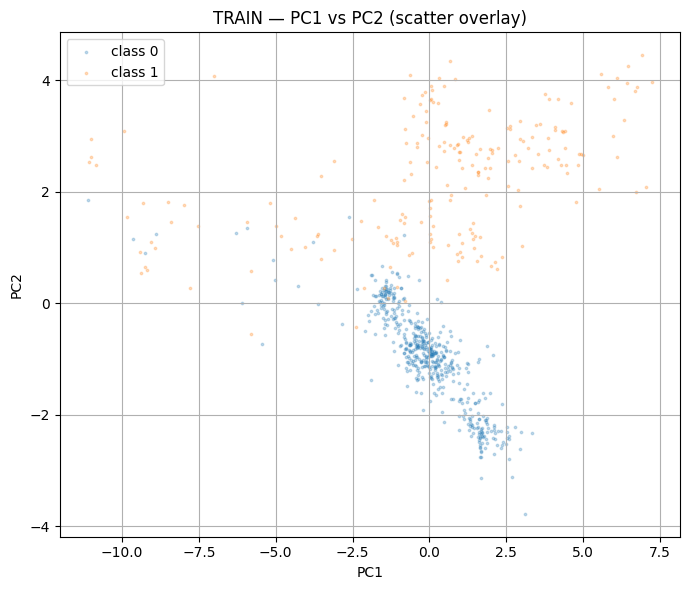

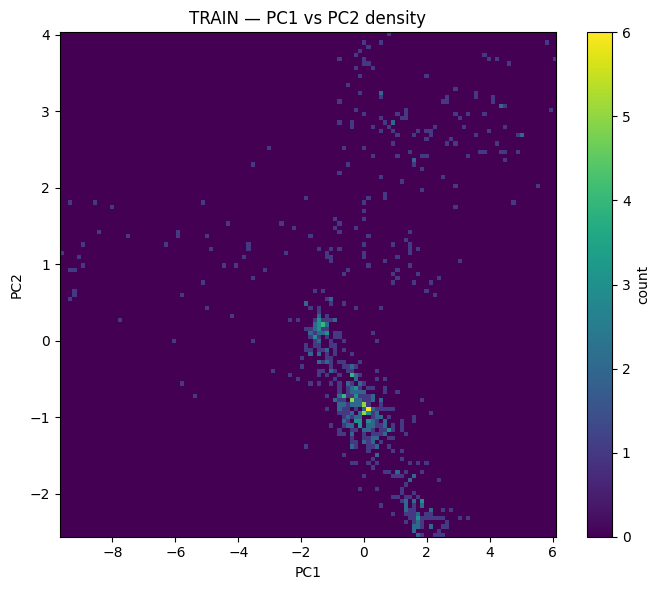

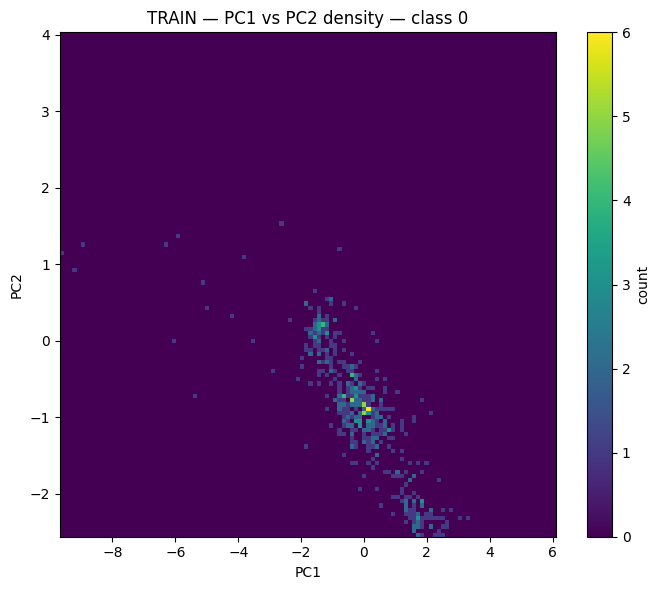

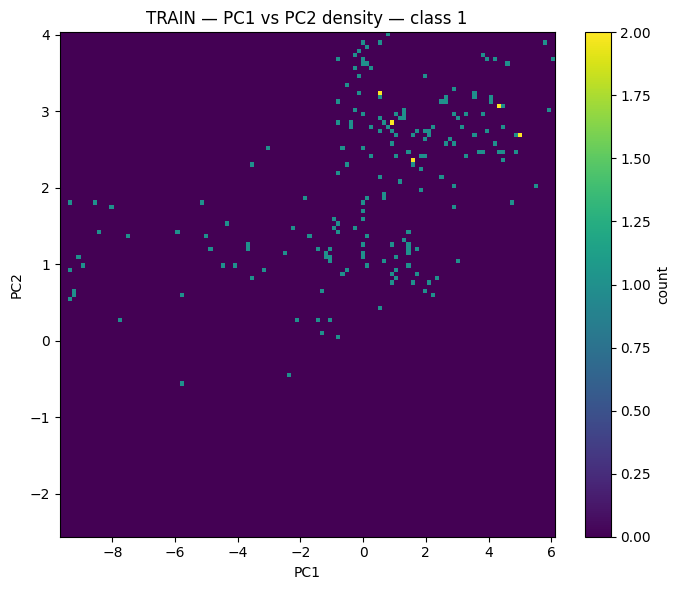

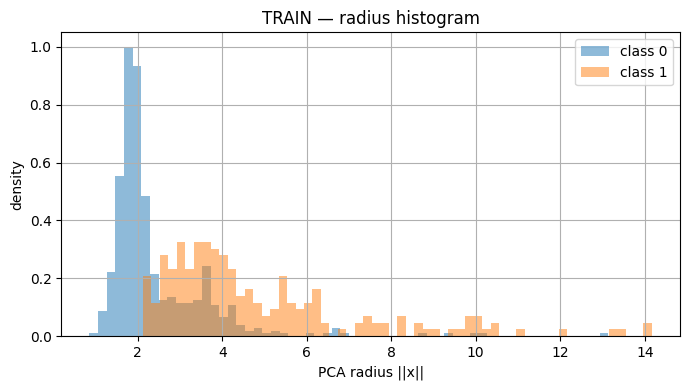

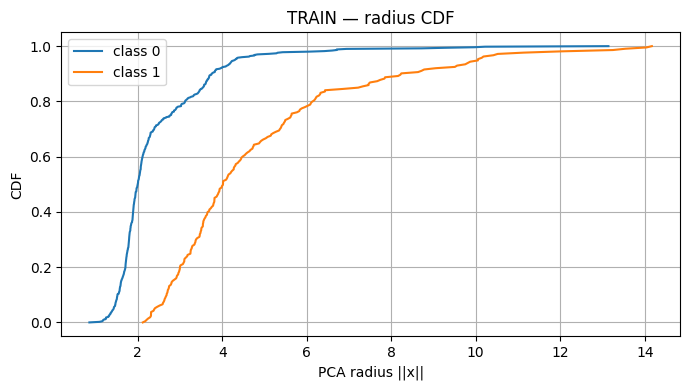

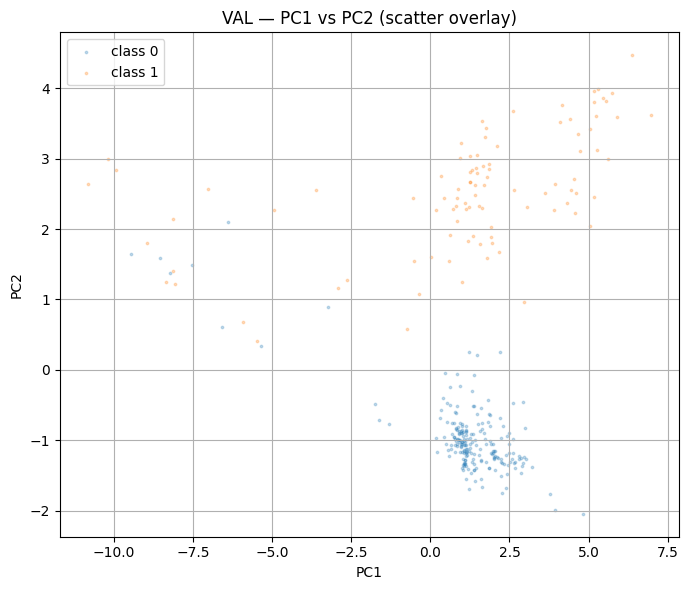

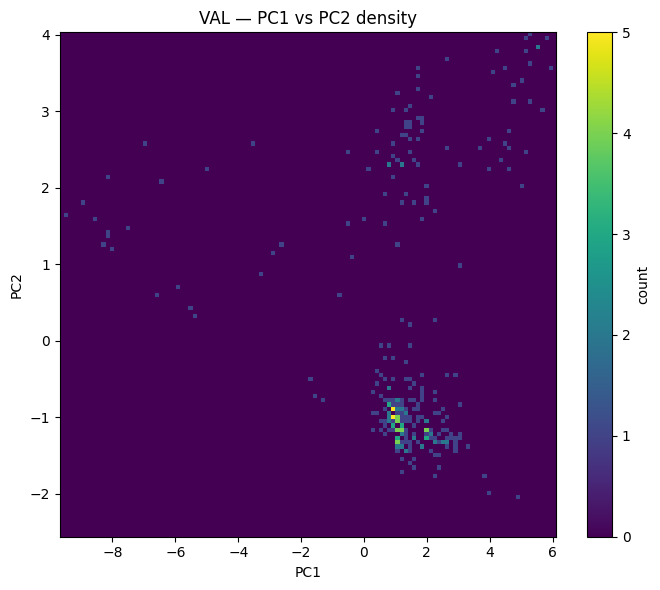

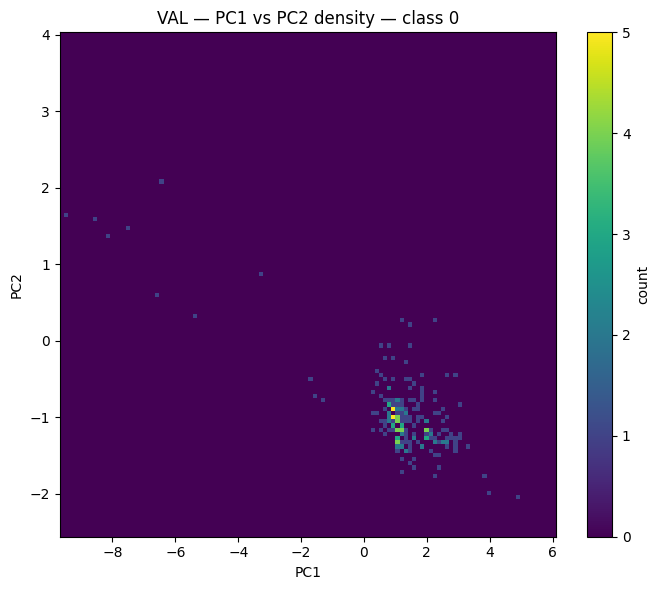

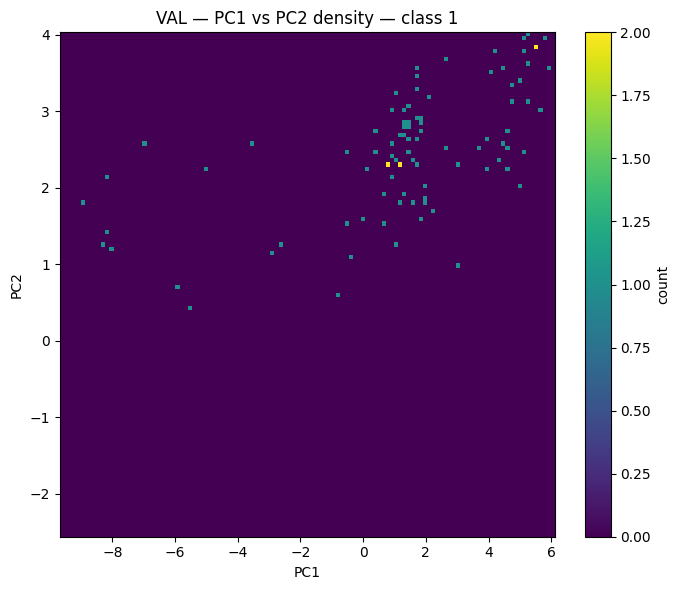

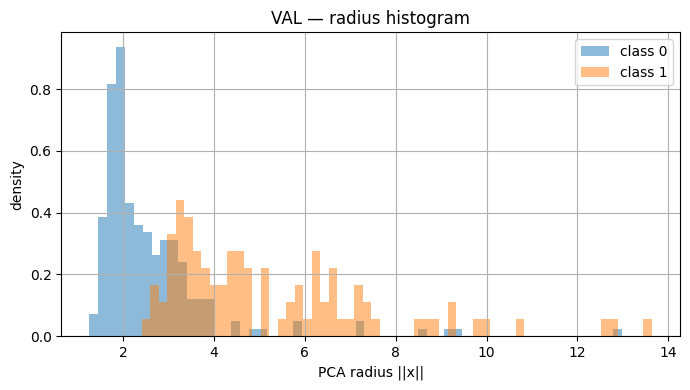

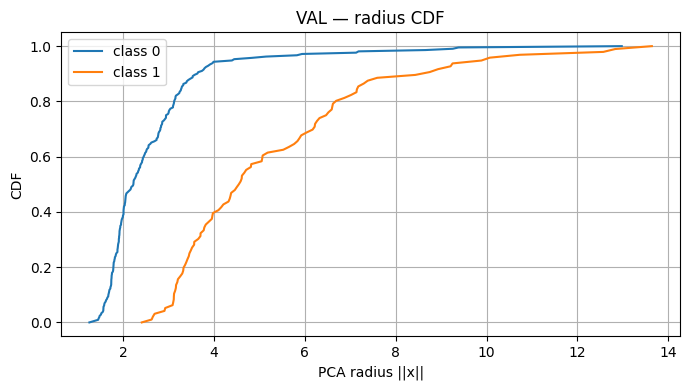

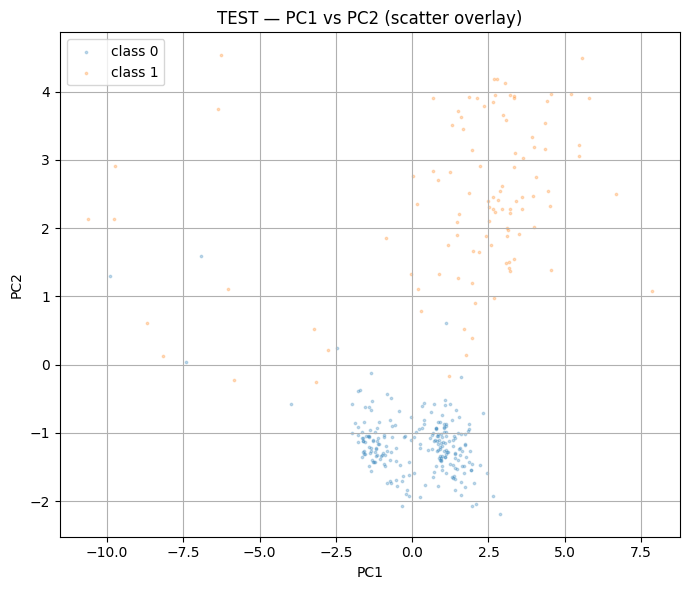

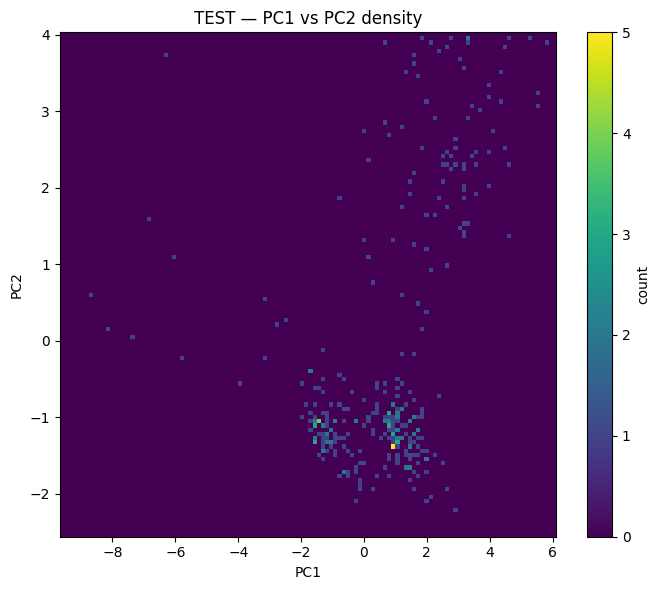

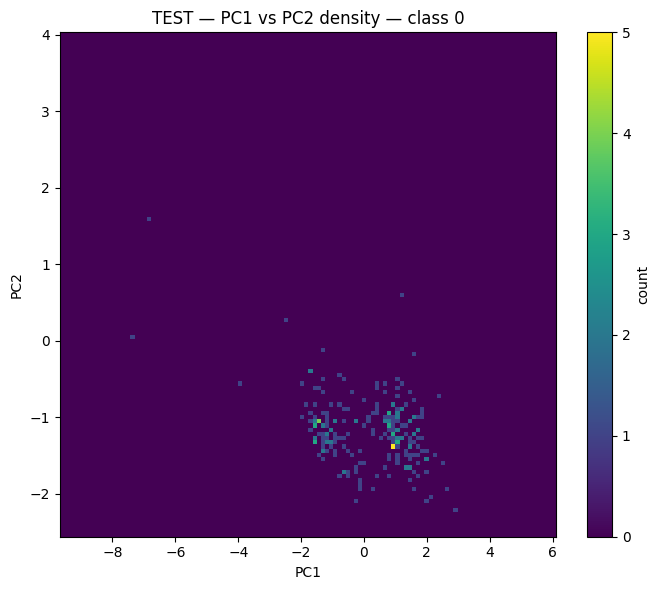

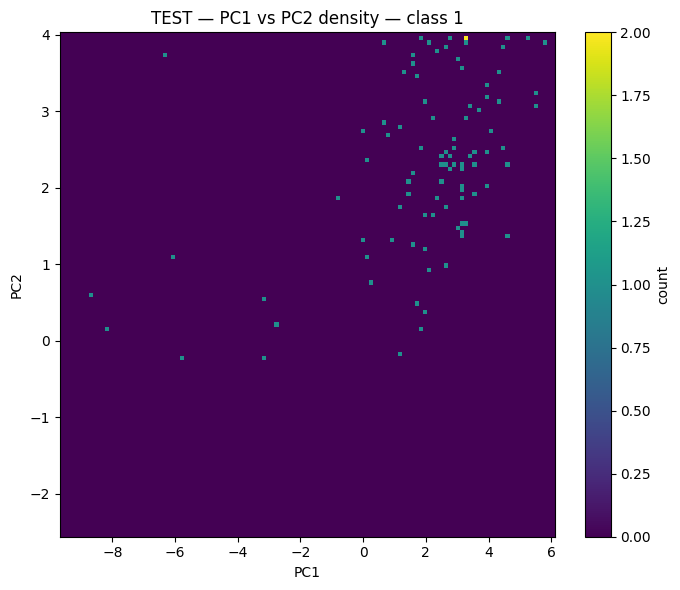

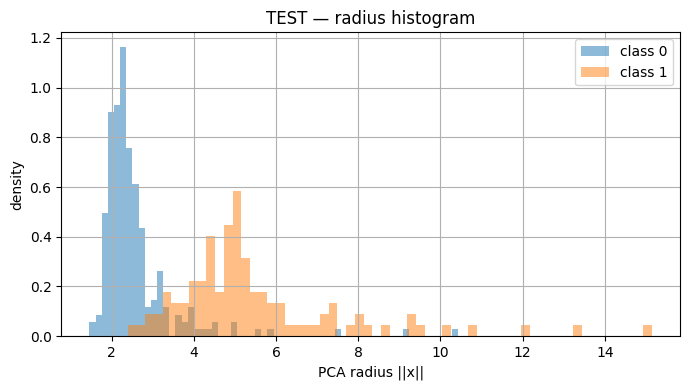

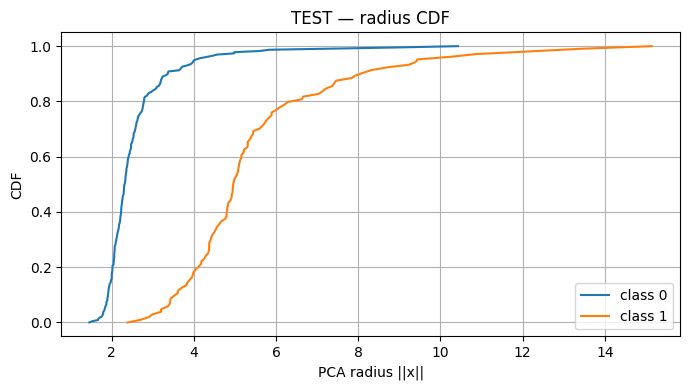

In [3]:
# Numeric summaries
summarize_split("TRAIN", Xtr_np, ytr_np)
summarize_split("VAL",   Xva_np, yva_np)
summarize_split("TEST",  Xte_np, yte_np)

# Consistent heatmap range across splits (so comparisons are fair)
all_X = np.vstack([Xtr_np, Xva_np, Xte_np])
x = all_X[:,0]; y = all_X[:,1]
range_xy = [[np.quantile(x, 0.01), np.quantile(x, 0.99)],
            [np.quantile(y, 0.01), np.quantile(y, 0.99)]]

# ---- TRAIN ----
plot_pca_scatter(Xtr_np, ytr_np, "TRAIN — PC1 vs PC2 (scatter overlay)")
plot_pca_heatmap(Xtr_np, "TRAIN — PC1 vs PC2 density", range_xy=range_xy)
plot_class_heatmaps(Xtr_np, ytr_np, "TRAIN — PC1 vs PC2 density", range_xy=range_xy)
plot_radius_curves(Xtr_np, ytr_np, "TRAIN")

# ---- VAL ----
plot_pca_scatter(Xva_np, yva_np, "VAL — PC1 vs PC2 (scatter overlay)")
plot_pca_heatmap(Xva_np, "VAL — PC1 vs PC2 density", range_xy=range_xy)
plot_class_heatmaps(Xva_np, yva_np, "VAL — PC1 vs PC2 density", range_xy=range_xy)
plot_radius_curves(Xva_np, yva_np, "VAL")

# ---- TEST ----
plot_pca_scatter(Xte_np, yte_np, "TEST — PC1 vs PC2 (scatter overlay)")
plot_pca_heatmap(Xte_np, "TEST — PC1 vs PC2 density", range_xy=range_xy)
plot_class_heatmaps(Xte_np, yte_np, "TEST — PC1 vs PC2 density", range_xy=range_xy)
plot_radius_curves(Xte_np, yte_np, "TEST")

plt.show()


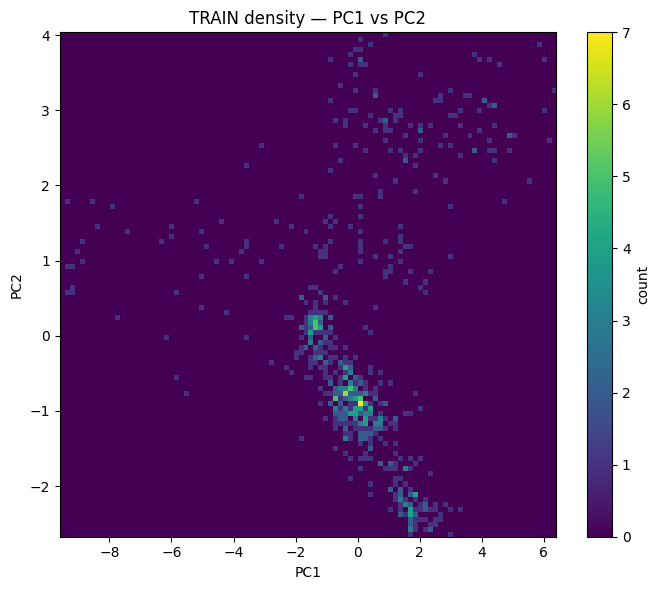

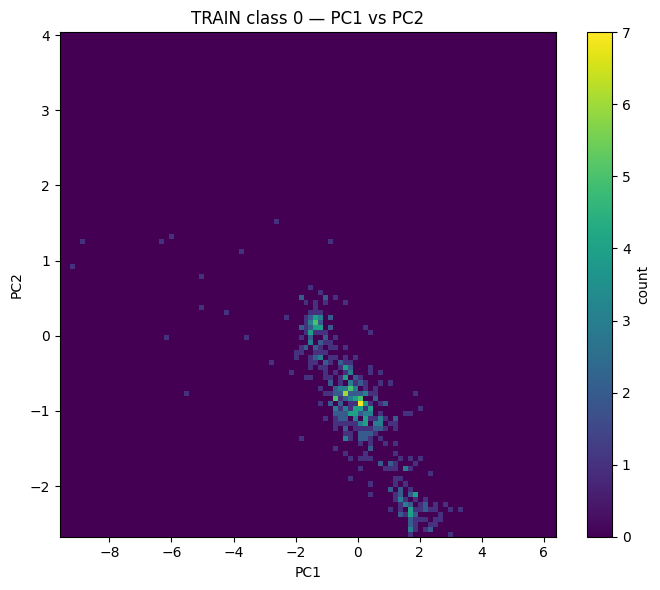

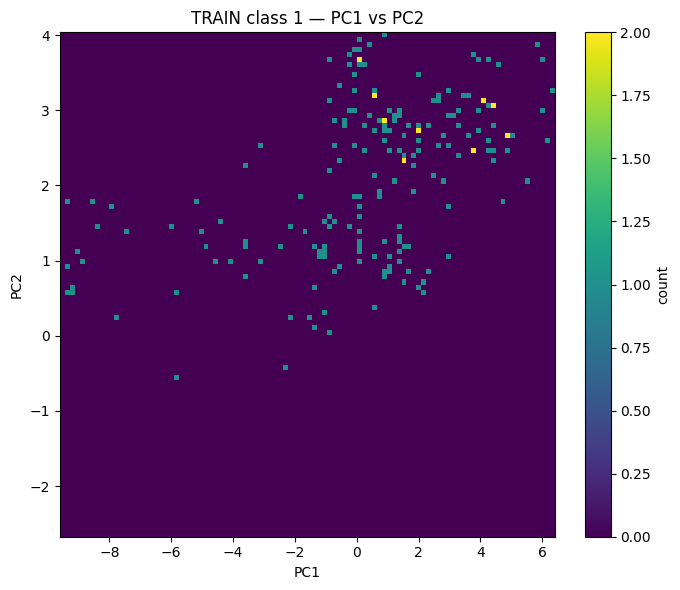

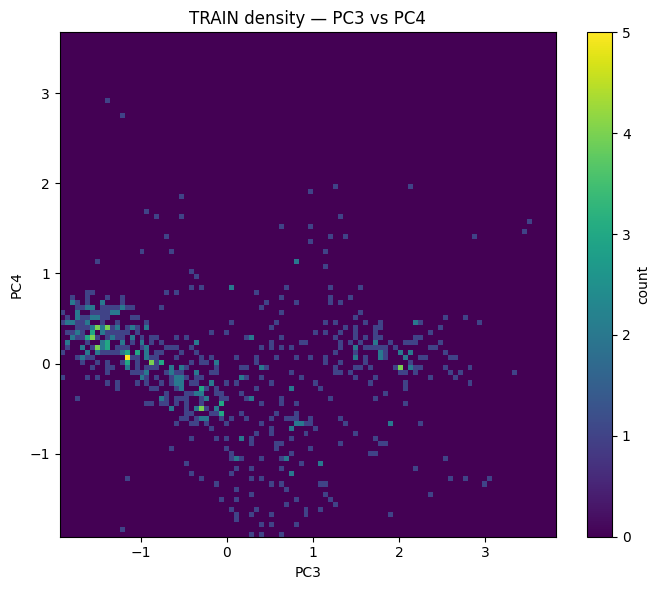

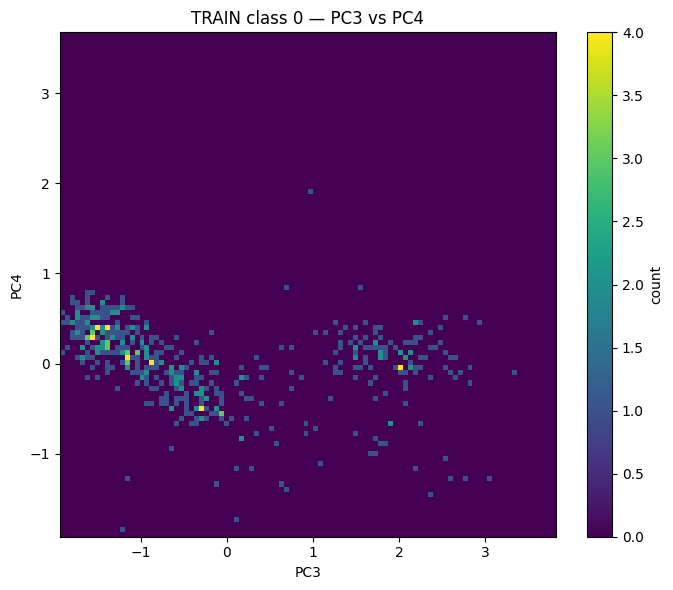

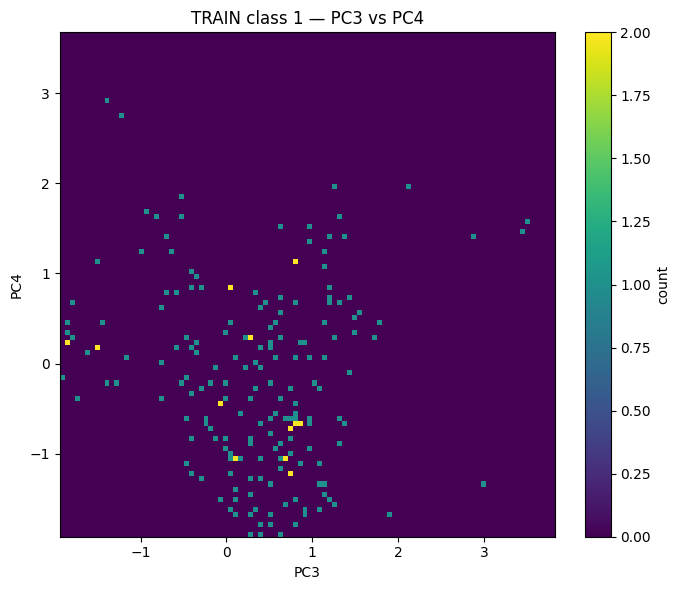

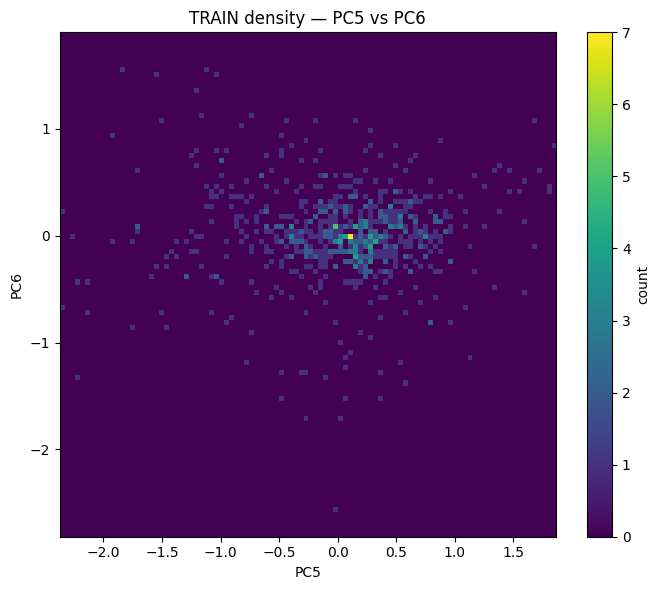

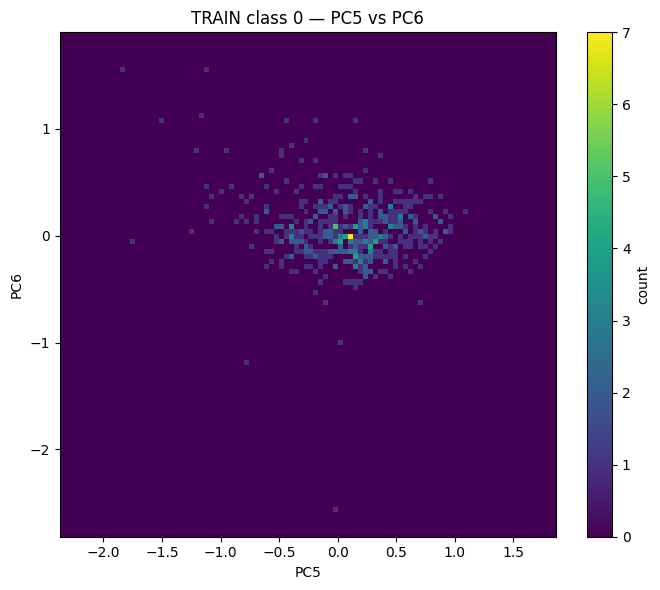

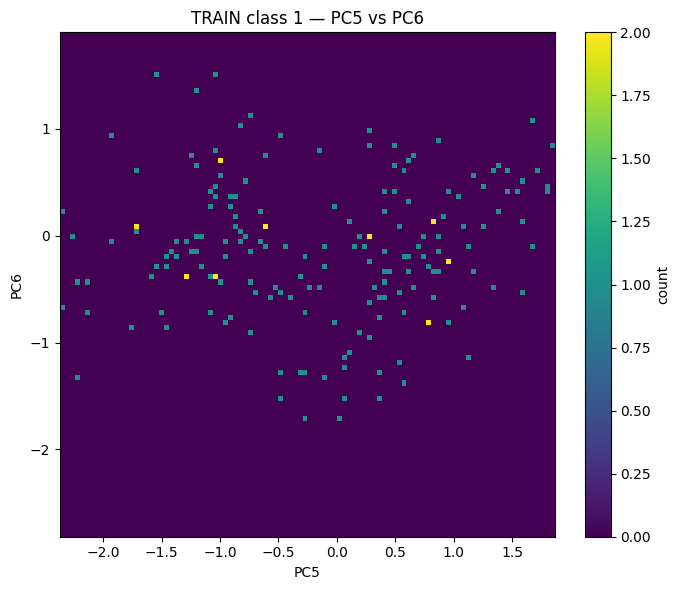

In [4]:
def plot_pair_heatmaps(X, y, pairs=None, bins=100, max_pairs=3, title_prefix=""):
    A = X.shape[1]
    if pairs is None:
        pairs = [(0,1), (2,3), (4,5), (6,7), (8,9)]
    pairs = [(i,j) for (i,j) in pairs if i < A and j < A][:max_pairs]

    for (i,j) in pairs:
        xi = X[:, i]; xj = X[:, j]
        # consistent range per pair
        range_xy = [[np.quantile(xi, 0.01), np.quantile(xi, 0.99)],
                    [np.quantile(xj, 0.01), np.quantile(xj, 0.99)]]

        # overall
        plt.figure(figsize=(7,6))
        H, xedges, yedges = np.histogram2d(xi, xj, bins=bins, range=range_xy)
        plt.imshow(H.T, origin="lower", aspect="auto",
                   extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
        plt.colorbar(label="count")
        plt.xlabel(f"PC{i+1}")
        plt.ylabel(f"PC{j+1}")
        plt.title(f"{title_prefix} density — PC{i+1} vs PC{j+1}")
        plt.tight_layout()

        # per class
        for cls in np.unique(y):
            m = (y == cls)
            plt.figure(figsize=(7,6))
            Hc, xedges, yedges = np.histogram2d(xi[m], xj[m], bins=bins, range=range_xy)
            plt.imshow(Hc.T, origin="lower", aspect="auto",
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
            plt.colorbar(label="count")
            plt.xlabel(f"PC{i+1}")
            plt.ylabel(f"PC{j+1}")
            plt.title(f"{title_prefix} class {int(cls)} — PC{i+1} vs PC{j+1}")
            plt.tight_layout()

# Example:
plot_pair_heatmaps(Xtr_np, ytr_np, title_prefix="TRAIN")
plt.show()
